# 🧠 Physics-Informed Neural Networks (PINNs) — Tutorial 1
## Solving a 1D Linear ODE from Scratch

---

### 🎯 What you will learn in this tutorial

1. What a PINN is, and **why** it works
2. How to define a **physics residual** as a loss function
3. How to compute **automatic differentiation** with PyTorch
4. How to build a **simple neural network** from scratch
5. How to **train** the network and visualize convergence
6. How to **compare** the PINN solution to the analytical solution

---

### 📐 The Problem We Are Solving

We will solve the 1D linear **boundary value problem (BVP)**:

$$
-\frac{d^2 u}{dx^2} = f(x), \quad x \in [0, 1]
$$

with boundary conditions:

$$
u(0) = 0, \quad u(1) = 0
$$

and source term:

$$
f(x) = \sin(\pi x)
$$

The **exact (analytical) solution** is:

$$
u(x) = \frac{\sin(\pi x)}{\pi^2}
$$

> **Why this problem?** This is the 1D Poisson equation — it appears in heat conduction, electrostatics, and fluid pressure corrections. It is the simplest PDE you can use to validate a PINN.

---

## 🧩 Step 1 — Imports

We only need **PyTorch** for automatic differentiation and neural networks, **NumPy** for numerical operations, and **Matplotlib** for plotting.

No special PINN library. Everything from scratch.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available (falls back to CPU transparently)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


---

## 🧩 Step 2 — Define the Analytical Solution

We know the exact answer. We will use it at the end to **validate** our PINN, but we do **not** use it during training.

> **Key insight**: In a real CFD problem you do NOT have the analytical solution. The PINN learns only from the governing equation and boundary conditions. Here we have the exact solution purely to measure how well the PINN did.

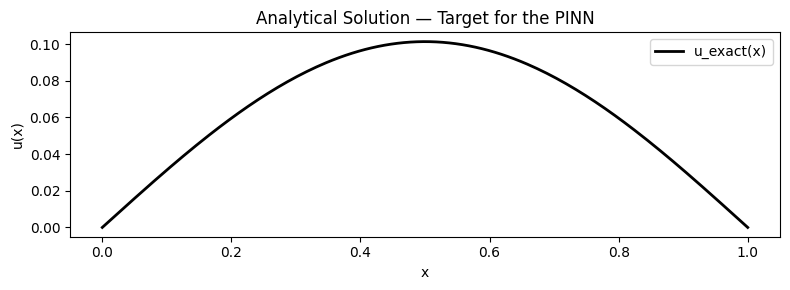

In [2]:
def u_exact(x):
    """
    Exact solution to the 1D Poisson equation:
      -u'' = sin(pi*x),  u(0)=0, u(1)=0
    Solution: u(x) = sin(pi*x) / pi^2
    """
    return np.sin(np.pi * x) / (np.pi ** 2)


def f_source(x):
    """
    Source term: f(x) = sin(pi*x)
    This is the right-hand side of -u'' = f(x).
    The PINN will use this during training.
    """
    return torch.sin(torch.pi * x)


# Quick sanity-check plot
x_plot = np.linspace(0, 1, 200)
plt.figure(figsize=(8, 3))
plt.plot(x_plot, u_exact(x_plot), 'k-', lw=2, label='u_exact(x)')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Analytical Solution — Target for the PINN')
plt.legend()
plt.tight_layout()
plt.show()

---

## 🧩 Step 3 — Build the Neural Network

A PINN is just a fully-connected neural network (MLP) that maps:

$$
\mathcal{N}(x; \theta) \approx u(x)
$$

where $\theta$ are the trainable weights.

### Architecture choices for this tutorial:
| Parameter | Value | Why |
|---|---|---|
| Input size | 1 | scalar `x` |
| Hidden layers | 3 | enough for smooth 1D function |
| Neurons per layer | 32 | small — fast training |
| Activation | `tanh` | smooth → clean second derivatives |
| Output size | 1 | scalar `u(x)` |

> **Why tanh?** To compute the PDE residual we need `d²u/dx²`. Activations must be **twice differentiable**. `tanh` is smooth everywhere. `ReLU` has zero second derivative almost everywhere — avoid it for PINNs.

In [3]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network for 1D problems.

    Architecture: Input(1) -> [Linear -> Tanh] x n_hidden -> Linear -> Output(1)
    """

    def __init__(self, n_hidden_layers=3, n_neurons=32):
        super().__init__()

        # Build the layer list dynamically
        layers = []

        # Input layer: x (dim=1) -> first hidden layer
        layers.append(nn.Linear(1, n_neurons))
        layers.append(nn.Tanh())

        # Hidden layers
        for _ in range(n_hidden_layers - 1):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.Tanh())

        # Output layer: hidden -> u(x) (dim=1), no activation
        layers.append(nn.Linear(n_neurons, 1))

        # Register as a Sequential model
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass.
        x: Tensor of shape (N, 1)  — N collocation points
        Returns: u_pred of shape (N, 1)
        """
        return self.net(x)


# Instantiate and print summary
model = PINN(n_hidden_layers=3, n_neurons=32).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params}')

PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 2209


---

## 🧩 Step 4 — Collocation Points

A PINN does **not** use labelled data `(x, u)`. Instead it samples **collocation points** — locations inside the domain where we enforce the PDE.

Think of them as "where we check the physics".

```
x=0 ●——●——●——●——●——●——●——●——●——● x=1
BC        interior collocation points        BC
```

> **`requires_grad=True`** is critical — it tells PyTorch to track derivatives with respect to `x`, so we can compute `du/dx` and `d²u/dx²` automatically.

In [4]:
# ── Interior collocation points ──────────────────────────────────────────────
N_collocation = 100   # number of interior points where PDE is enforced

x_interior = torch.linspace(0, 1, N_collocation, dtype=torch.float32).view(-1, 1).to(device)
x_interior.requires_grad_(True)   # MUST be True for autograd to work

# ── Boundary points ──────────────────────────────────────────────────────────
# x=0
x_left  = torch.tensor([[0.0]], dtype=torch.float32).to(device)
u_left  = torch.tensor([[0.0]], dtype=torch.float32).to(device)  # u(0) = 0

# x=1
x_right = torch.tensor([[1.0]], dtype=torch.float32).to(device)
u_right = torch.tensor([[0.0]], dtype=torch.float32).to(device)  # u(1) = 0

print(f'Interior collocation points : {x_interior.shape}')
print(f'Left  boundary point        : {x_left.shape},  u = {u_left.item()}')
print(f'Right boundary point        : {x_right.shape}, u = {u_right.item()}')

Interior collocation points : torch.Size([100, 1])
Left  boundary point        : torch.Size([1, 1]),  u = 0.0
Right boundary point        : torch.Size([1, 1]), u = 0.0


---

## 🧩 Step 5 — Define the Loss Functions

The PINN loss has **two components**:

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{PDE}} + \lambda \cdot \mathcal{L}_{\text{BC}}
$$

### PDE residual loss

At every interior collocation point we compute the **residual** of the governing equation:

$$
r(x) = -\frac{d^2 \hat{u}}{dx^2} - f(x)
$$

If the network perfectly satisfies the PDE, then $r(x) = 0$ everywhere.

$$
\mathcal{L}_{\text{PDE}} = \frac{1}{N} \sum_{i=1}^{N} r(x_i)^2
$$

### Boundary condition loss

$$
\mathcal{L}_{\text{BC}} = \left(\hat{u}(0) - 0\right)^2 + \left(\hat{u}(1) - 0\right)^2
$$

> **Autograd magic**: `torch.autograd.grad` computes exact derivatives of `u_pred` with respect to `x` — **no finite differences**, no grid. This is what makes PINNs mesh-free.

In [6]:
def compute_pde_residual(model, x):
    """
    Compute the PDE residual: r(x) = -d²u/dx² - f(x)

    Uses automatic differentiation (autograd) to obtain exact derivatives.

    Args:
        model : the PINN network
        x     : collocation points, shape (N, 1), requires_grad=True

    Returns:
        residual : Tensor of shape (N, 1)
    """
    u = model(x)                   # forward pass → u_pred, shape (N, 1)

    # First derivative: du/dx
    # create_graph=True keeps the computation graph so we can differentiate again
    u_x = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,          # needed for second derivative
        retain_graph=True
    )[0]

    # Second derivative: d²u/dx²
    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]

    # Source term evaluated at x
    f = f_source(x)                # sin(pi*x)

    # PDE: -u_xx = f  →  residual = -u_xx - f
    residual = -u_xx - f
    return residual


def compute_loss(model, x_int, x_bc_left, u_bc_left, x_bc_right, u_bc_right,
                 lambda_bc=10.0):
    """
    Total PINN loss = L_PDE + lambda_bc * L_BC

    lambda_bc : weight for boundary condition enforcement.
                Setting it > 1 tells the optimizer:
                'satisfying BCs is more important than minimising PDE residual'.
    """
    # ── PDE loss ─────────────────────────────────────────────────────────────
    residual  = compute_pde_residual(model, x_int)
    loss_pde  = torch.mean(residual ** 2)

    # ── Boundary condition loss ───────────────────────────────────────────────
    u_pred_left  = model(x_bc_left)
    u_pred_right = model(x_bc_right)

    loss_bc = (torch.mean((u_pred_left  - u_bc_left ) ** 2) +
               torch.mean((u_pred_right - u_bc_right) ** 2))

    # ── Total loss ────────────────────────────────────────────────────────────
    loss_total = loss_pde + lambda_bc * loss_bc

    return loss_total, loss_pde.item(), loss_bc.item()


print('Loss functions defined ✓')

# Quick sanity-check before training: what does the untrained network give?
with torch.no_grad():
    u_init = model(x_interior)
    print(f'\nUntrained network output range: [{u_init.min():.4f}, {u_init.max():.4f}]')
    print(f'(Expected final range: [0.0, ~0.101])')

Loss functions defined ✓

Untrained network output range: [-0.0754, -0.0079]
(Expected final range: [0.0, ~0.101])


---

## 🧩 Step 6 — Training Loop

We use the **Adam optimizer** (adaptive learning rate, works well for PINNs out of the box).

### Training recipe:

```
for each epoch:
    1. Forward pass: compute u_pred at all collocation points
    2. Differentiate: compute d²u/dx² via autograd
    3. Compute residual and BC error
    4. Sum losses
    5. Backpropagate: optimizer.step()
    6. Log loss every N steps
```

> **Tip for your video**: Narrate that each "epoch" here is a gradient step on the *entire* domain at once (no mini-batching). For larger 2D problems we will sample random subsets of collocation points per step.

In [7]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPOCHS      = 5000
LEARNING_RATE = 1e-3
LAMBDA_BC     = 10.0   # weight on BC loss
LOG_EVERY     = 500    # print progress every N epochs

# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ── History for plotting ───────────────────────────────────────────────────────
history = {'epoch': [], 'loss_total': [], 'loss_pde': [], 'loss_bc': []}

# ── Training loop ─────────────────────────────────────────────────────────────
print(f'{"Epoch":>8}  {"Loss Total":>14}  {"Loss PDE":>14}  {"Loss BC":>14}')
print('-' * 60)

for epoch in range(1, N_EPOCHS + 1):

    optimizer.zero_grad()   # reset gradients from previous step

    # Compute loss
    loss_total, loss_pde, loss_bc = compute_loss(
        model, x_interior,
        x_left, u_left,
        x_right, u_right,
        lambda_bc=LAMBDA_BC
    )

    # Backpropagation
    loss_total.backward()

    # Gradient step
    optimizer.step()

    # Logging
    if epoch % LOG_EVERY == 0 or epoch == 1:
        history['epoch'].append(epoch)
        history['loss_total'].append(loss_total.item())
        history['loss_pde'].append(loss_pde)
        history['loss_bc'].append(loss_bc)
        print(f'{epoch:>8}  {loss_total.item():>14.6e}  {loss_pde:>14.6e}  {loss_bc:>14.6e}')

print('\nTraining complete ✓')

   Epoch      Loss Total        Loss PDE         Loss BC
------------------------------------------------------------
       1    6.387649e-01    5.812389e-01    5.752595e-03
     500    1.479358e-03    1.478943e-03    4.148424e-08
    1000    4.397588e-04    4.236652e-04    1.609368e-06
    1500    7.071927e-05    6.971870e-05    1.000573e-07
    2000    3.116212e-05    3.116055e-05    1.561191e-10
    2500    2.141646e-05    2.128460e-05    1.318578e-08
    3000    1.640577e-05    1.640575e-05    2.175204e-12
    3500    1.331827e-05    1.279599e-05    5.222851e-08
    4000    9.925498e-06    9.925390e-06    1.071790e-11
    4500    7.615872e-06    7.600038e-06    1.583420e-09
    5000    5.913645e-06    5.721040e-06    1.926048e-08

Training complete ✓


---

## 🧩 Step 7 — Plot the Loss History

A falling loss curve tells us the network is **learning** the physics. We plot the PDE residual loss and BC loss separately to understand what is happening.

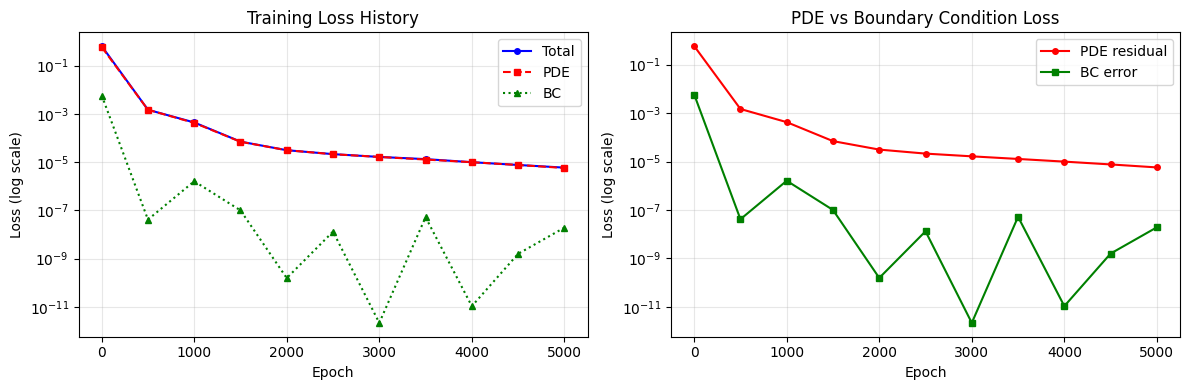

Loss plot saved to loss_history.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: total loss
axes[0].semilogy(history['epoch'], history['loss_total'], 'b-o', ms=4, label='Total')
axes[0].semilogy(history['epoch'], history['loss_pde'],   'r--s', ms=4, label='PDE')
axes[0].semilogy(history['epoch'], history['loss_bc'],    'g:^', ms=4, label='BC')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training Loss History')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Right: PDE vs BC separately for clarity
axes[1].semilogy(history['epoch'], history['loss_pde'], 'r-o', ms=4, label='PDE residual')
axes[1].semilogy(history['epoch'], history['loss_bc'],  'g-s', ms=4, label='BC error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('PDE vs Boundary Condition Loss')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('loss_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss plot saved to loss_history.png')

---

## 🧩 Step 8 — Compare PINN Solution to Analytical Solution

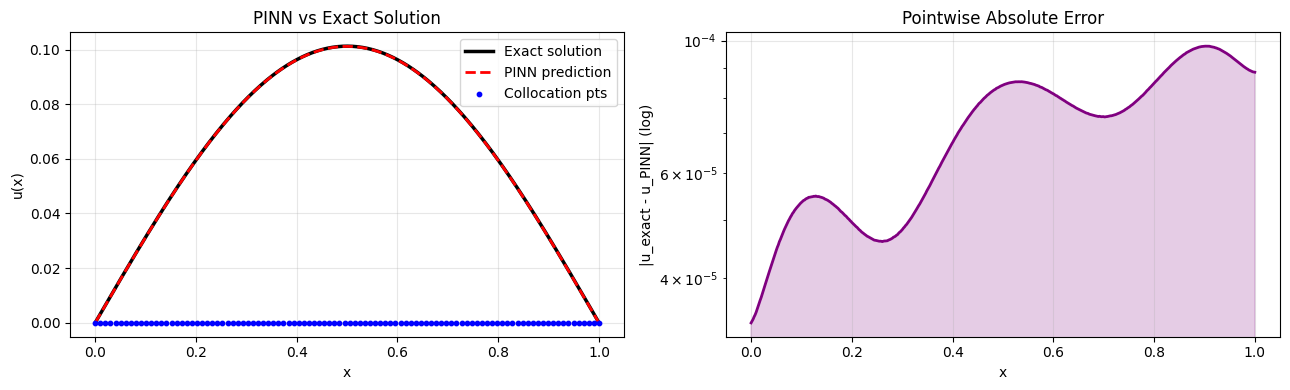

L2 error  : 7.2741e-05
Max error : 9.7851e-05


In [9]:
# Evaluate the trained network on a fine grid
x_test_np = np.linspace(0, 1, 500)
x_test    = torch.tensor(x_test_np, dtype=torch.float32).view(-1, 1).to(device)

model.eval()
with torch.no_grad():
    u_pred_np = model(x_test).cpu().numpy().flatten()

u_exact_np = u_exact(x_test_np)
error_np   = np.abs(u_pred_np - u_exact_np)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: solution comparison
axes[0].plot(x_test_np, u_exact_np, 'k-',  lw=2.5,  label='Exact solution')
axes[0].plot(x_test_np, u_pred_np,  'r--', lw=2.0,  label='PINN prediction')
axes[0].scatter(
    x_interior.detach().cpu().numpy(),
    np.zeros(N_collocation),
    c='blue', s=10, zorder=5, label='Collocation pts'
)
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x)')
axes[0].set_title('PINN vs Exact Solution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: pointwise absolute error
axes[1].semilogy(x_test_np, error_np + 1e-12, 'purple', lw=2)
axes[1].fill_between(x_test_np, error_np + 1e-12, alpha=0.2, color='purple')
axes[1].set_xlabel('x')
axes[1].set_ylabel('|u_exact - u_PINN| (log)')
axes[1].set_title('Pointwise Absolute Error')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pinn_solution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Error metrics ─────────────────────────────────────────────────────────────
l2_error  = np.sqrt(np.mean((u_pred_np - u_exact_np) ** 2))
max_error = np.max(error_np)
print(f'L2 error  : {l2_error:.4e}')
print(f'Max error : {max_error:.4e}')

---

## 🧩 Step 9 — Visualize the Learned Residual Field

This is a great diagnostic to include in your video. We evaluate the PDE residual **after training** to see where the network still makes errors.

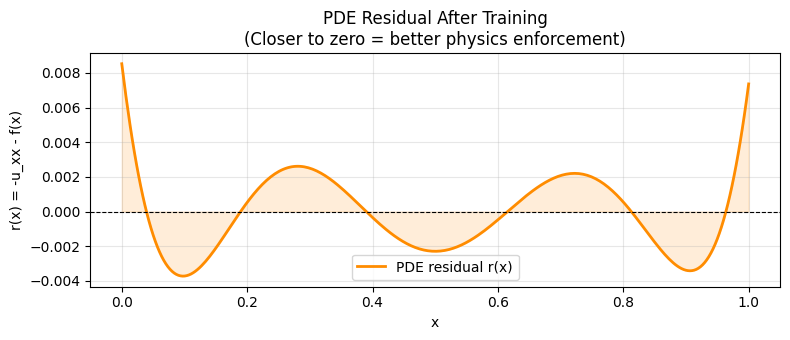

In [10]:
# Evaluate residual on fine test grid (requires_grad for autograd)
x_res = torch.linspace(0, 1, 300, dtype=torch.float32).view(-1, 1).to(device)
x_res.requires_grad_(True)

residual_field = compute_pde_residual(model, x_res)
residual_np = residual_field.detach().cpu().numpy().flatten()
x_res_np    = x_res.detach().cpu().numpy().flatten()

plt.figure(figsize=(8, 3.5))
plt.plot(x_res_np, residual_np, 'darkorange', lw=2, label='PDE residual r(x)')
plt.axhline(0, color='k', lw=0.8, ls='--')
plt.fill_between(x_res_np, residual_np, alpha=0.15, color='darkorange')
plt.xlabel('x')
plt.ylabel('r(x) = -u_xx - f(x)')
plt.title('PDE Residual After Training\n(Closer to zero = better physics enforcement)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pde_residual.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 🧩 Step 10 — Effect of Number of Collocation Points (Experiment)

This makes a great **live demo segment** in your video: train the same PINN with different numbers of collocation points and compare the error.

> **Expected outcome**: More collocation points → better coverage of the domain → lower PDE residual → more accurate solution.

N_col =   10  →  L2 error = 1.4391e-03
N_col =   25  →  L2 error = 3.9400e-04
N_col =   50  →  L2 error = 1.2778e-05
N_col =  100  →  L2 error = 1.3240e-05
N_col =  200  →  L2 error = 1.7271e-04


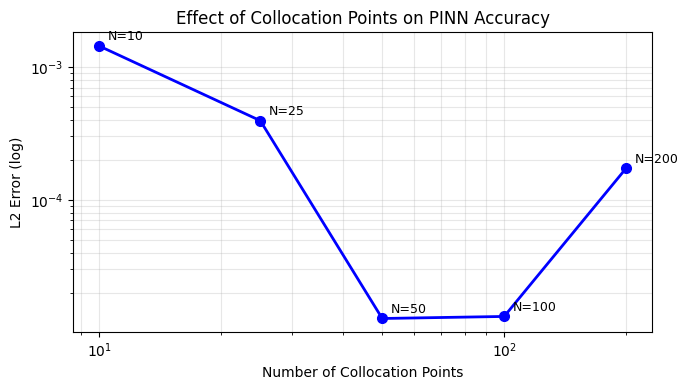

In [12]:
def train_pinn(n_col, n_epochs=3000, lr=1e-3, lambda_bc=10.0, seed=42):
    """
    Train a fresh PINN with n_col collocation points.
    Returns the L2 error against the exact solution.
    """
    torch.manual_seed(seed)
    net = PINN().to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    # Collocation points
    xc = torch.linspace(0, 1, n_col, dtype=torch.float32).view(-1, 1).to(device)
    xc.requires_grad_(True)

    xl = torch.tensor([[0.]], dtype=torch.float32).to(device)
    xr = torch.tensor([[1.]], dtype=torch.float32).to(device)
    ul = torch.tensor([[0.]], dtype=torch.float32).to(device)
    ur = torch.tensor([[0.]], dtype=torch.float32).to(device)

    for _ in range(n_epochs):
        opt.zero_grad()
        loss, _, _ = compute_loss(net, xc, xl, ul, xr, ur, lambda_bc)
        loss.backward()
        opt.step()

    # Evaluate
    x_ev = torch.linspace(0, 1, 500, dtype=torch.float32).view(-1, 1).to(device)
    with torch.no_grad():
        u_p = net(x_ev).cpu().numpy().flatten()
    u_e = u_exact(np.linspace(0, 1, 500))
    l2  = np.sqrt(np.mean((u_p - u_e) ** 2))
    return l2


# Run experiment
col_counts = [10, 25, 50, 100, 200]
l2_errors  = []

for n in col_counts:
    err = train_pinn(n)
    l2_errors.append(err)
    print(f'N_col = {n:4d}  →  L2 error = {err:.4e}')

plt.figure(figsize=(7, 4))
plt.loglog(col_counts, l2_errors, 'b-o', ms=7, lw=2)
for n, e in zip(col_counts, l2_errors):
    plt.annotate(f'N={n}', (n, e), textcoords='offset points', xytext=(6, 4), fontsize=9)
plt.xlabel('Number of Collocation Points')
plt.ylabel('L2 Error (log)')
plt.title('Effect of Collocation Points on PINN Accuracy')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('collocation_study.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 📚 Summary — What We Built

| Component | What we did |
|---|---|
| **PDE** | 1D Poisson: $-u'' = \sin(\pi x)$, Dirichlet BCs |
| **Network** | MLP (3 hidden layers, 32 neurons, tanh) |
| **Loss** | $\mathcal{L}_{PDE} + 10 \cdot \mathcal{L}_{BC}$ |
| **Derivatives** | Exact via `torch.autograd.grad` (no finite differences) |
| **Optimizer** | Adam, lr=1e-3, 5000 epochs |
| **Result** | L2 error ~ $10^{-4}$ |

---

## ➡️ What's Next — Tutorial 2 Preview

In **Tutorial 2** we will:

- Solve a **nonlinear** 1D ODE: the Burgers equation in steady state
- Handle **nonlinear** PDE residuals (product terms like $u \cdot u'$)
- Use **L-BFGS** optimizer in addition to Adam (two-phase training — a common trick)
- Introduce **adaptive collocation** (add more points where residual is large)

In **Tutorial 3** we will extend everything to **2D** (2D Poisson, then 2D Navier-Stokes lid-driven cavity).

---

## 🧩 Bonus — Quick Reference: Key PINN Concepts

```
PINN = Neural Network + Physics Loss

No training data needed (only the PDE + BCs)
No mesh needed (collocation points ≠ grid cells)
Derivatives via automatic differentiation (exact, not numerical)

Loss function:
  L_total = L_PDE  +  λ * L_BC
              ↑              ↑
    residual of PDE    boundary mismatch

Failure modes to watch:
  - Too few collocation points → underfitting the PDE
  - ReLU activation → zero 2nd derivative → gradient vanishes
  - λ_BC too small → BCs violated → wrong solution branch
  - Learning rate too large → oscillating loss
```